In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
%matplotlib inline
import matplotlib.pyplot as plt

# --- Configuration ---
CSV_PATH = "rates.csv"
BATCH_SIZE = 32
LEARNING_RATE = 0.001
TEST_SPLIT = 0.2

# Train NN for model surrogate
Here I train a NN for predicting the reaction rate of N2O given T,xNH3, xNO, xO2. 
Several different studies are performed.
- Effect of input scaling (standardization)
- Error study:
    - Vary number of layers and neurons per layers
    - Varying activation functions
- We test the ability of the network to extrapolate reaction rates from lower temperatures to higher temperatures
- Conclusions: I can replicate the results from my dissertation and it shows that NN are a promising alternative for surrogate modeling.

As a note we clip the gradients to 1 for stability

In [2]:
class ReactionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values)
        self.y = torch.FloatTensor(y.values).unsqueeze(1)  
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
class SurrogateModel(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 64], activation='ReLU'):
        """
        Args:
            input_dim: Number of input features
            hidden_dims: List of hidden layer dimensions (e.g., [128, 64, 32])
            activation: Activation function name ('ReLU', 'Tanh', 'LeakyReLU')
        """
        super().__init__()
        
        # Map string to activation class
        activations = {
            'ReLU': nn.ReLU,
            'Tanh': nn.Tanh,
            'Sigmoid': nn.Sigmoid,
            'LeakyReLU': nn.LeakyReLU,
            'SiLU': nn.SiLU
        }
        self.act_fn = activations.get(activation, nn.ReLU)
        
        # Build layers dynamically
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                self.act_fn()
            ])
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)
    

def train_model(model, train_loader, val_loader, learning_rate=LEARNING_RATE):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    train_losses, val_losses = [], []
    
    for epoch in range(EPOCHS):
        # Training
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            predictions = model(X_batch).squeeze()
            loss = criterion(predictions, y_batch.squeeze())
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                val_predictions = model(X_val).squeeze()
                val_loss += criterion(val_predictions, y_val.squeeze()).item()
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {train_loss/len(train_loader):.6f}, Val Loss: {val_loss/len(val_loader):.6f}")
        
        train_losses.append(train_loss/len(train_loader))
        val_losses.append(val_loss/len(val_loader))
    
    return train_losses, val_losses

In [3]:
def plot_results(train_losses, val_losses, predictions):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.title('Training History')

    plt.subplot(1, 2, 2)
    plt.scatter(y_val, predictions, alpha=0.5)
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.title('Model Performance')
    plt.tight_layout()
    plt.show()


In [4]:
def load_data2(scaling=True, random_state=1):
    df = pd.read_csv(CSV_PATH)
    df = df[['T', 'xNH3', 'xO2', 'xNO', 'rN2O']]
    df = df.sample(10000, random_state=1)

    # Transform and split features and target
    target_col = 'rN2O'
    df[target_col] = np.log(df[target_col])
    df['T'] = 1/df['T']
    df['xNH3'] = np.log(df['xNH3'])
    df['xO2'] = np.log(df['xO2'])
    df['xNO'] = np.log(df['xNO'])

    from sklearn.model_selection import train_test_split

    feature_cols = [col for col in df.columns if col != target_col]
    X = df[feature_cols]
    y = df[target_col]
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=TEST_SPLIT, random_state=random_state)
    
    if scaling:
        X_mean, X_std = X_train.mean(), X_train.std()
        y_mean, y_std = y_train.mean(), y_train.std()
        
        X_train = (X_train - X_mean) / X_std
        X_val = (X_val - X_mean) / X_std  # Use train stats
        
        y_train = (y_train - y_mean) / y_std
        y_val = (y_val - y_mean) / y_std


    # Create data loaders
    train_dataset = ReactionDataset(X_train, y_train)
    val_dataset = ReactionDataset(X_val, y_val)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
    return train_dataset, val_dataset, train_loader, val_loader, feature_cols, X_val, y_val



In [5]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

def load_data(csv_path=CSV_PATH, test_split=0.2, batch_size=32, scaling=True, max_train_temp=None, 
              sample_size=10000, random_state=1):
    df = pd.read_csv(csv_path)
    df = df[['T', 'xNH3', 'xO2', 'xNO', 'rN2O']]
    df = df.sample(sample_size, random_state=random_state) # for speed
    
    train_idx, val_idx = train_test_split(df.index, test_size=test_split, 
                                          random_state=random_state)
    df_train = df.loc[train_idx].copy()
    df_val = df.loc[val_idx].copy()

    print("Train T range:", df_train['T'].min(), "to", df_train['T'].max())
    print("Val T range:", df_val['T'].min(), "to", df_val['T'].max())
    
    if max_train_temp is not None:
        df_train = df_train[df_train['T'] <= max_train_temp]
    
    target_col = 'rN2O'
    for col in [target_col, 'xNH3', 'xO2', 'xNO']:
        df_train[col] = np.log(df_train[col])
        df_val[col] = np.log(df_val[col])
   
    df_train['T'] = 1 / df_train['T']
    df_val['T'] = 1 / df_val['T']
   
    feature_cols = ['T', 'xNH3', 'xO2', 'xNO']
    X_train, y_train = df_train[feature_cols], df_train[target_col]
    X_val, y_val = df_val[feature_cols], df_val[target_col]
   
    if scaling:
        x_mean = X_train.mean()
        x_std = X_train.std()
        X_train = (X_train - x_mean) / x_std
        X_val = (X_val - x_mean) / x_std
        
        y_mean = y_train.mean()
        y_std = y_train.std()
        y_train = (y_train - y_mean) / y_std
        y_val = (y_val - y_mean) / y_std
    
    train_dataset = ReactionDataset(X_train, y_train)
    val_dataset = ReactionDataset(X_val, y_val)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    
    return train_dataset, val_dataset, train_loader, val_loader, feature_cols, X_val, y_val, X_train, y_train

In [6]:
train_dataset, val_dataset, train_loader, val_loader, feature_cols, X_val, y_val, X_train, y_train = load_data()

Train T range: 500.052567768837 to 1499.8862778372106
Val T range: 500.8647911688058 to 1498.833605698965


### Effect of scaling on shallow networks
Scaling refers to standardizing the inputs to be roughly of the order of +/- 1 by substracting its mean and dividing by its standard deviation
We get a 2x1. We also study the performance on simple networks

Train T range: 500.052567768837 to 1499.8862778372106
Val T range: 500.8647911688058 to 1498.833605698965
Training model with 4 input features...
Epoch [20/300] - Train Loss: 10.625045, Val Loss: 10.185870
Epoch [40/300] - Train Loss: 10.545185, Val Loss: 10.120732
Epoch [60/300] - Train Loss: 10.360235, Val Loss: 9.953275
Epoch [80/300] - Train Loss: 9.963538, Val Loss: 9.535546
Epoch [100/300] - Train Loss: 9.315938, Val Loss: 8.892598
Epoch [120/300] - Train Loss: 8.508280, Val Loss: 8.071888
Epoch [140/300] - Train Loss: 7.511296, Val Loss: 7.081360
Epoch [160/300] - Train Loss: 6.437162, Val Loss: 6.431598
Epoch [180/300] - Train Loss: 5.522304, Val Loss: 5.201076
Epoch [200/300] - Train Loss: 4.771345, Val Loss: 4.502783
Epoch [220/300] - Train Loss: 4.187274, Val Loss: 4.080575
Epoch [240/300] - Train Loss: 3.674400, Val Loss: 3.635941
Epoch [260/300] - Train Loss: 3.419960, Val Loss: 3.397907
Epoch [280/300] - Train Loss: 3.228871, Val Loss: 3.370160
Epoch [300/300] - Train Los

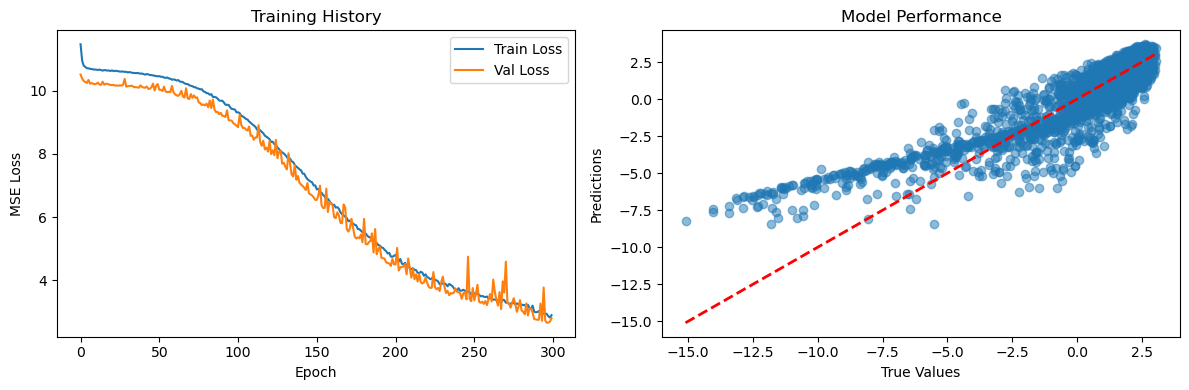

In [7]:
EPOCHS = 300
train_dataset, val_dataset, train_loader, val_loader, feature_cols, X_val, y_val, X_train, y_train = load_data(scaling=False)

model = SurrogateModel(input_dim=len(feature_cols), hidden_dims=[64])
print(f"Training model with {len(feature_cols)} input features...")
train_losses, val_losses = train_model(model, train_loader, val_loader, learning_rate=1E-3)

# 6. Evaluation
model.eval()
with torch.no_grad():
    X_test = torch.FloatTensor(X_val.values)
    predictions = model(X_test).numpy().flatten()

plot_results(train_losses, val_losses, predictions)

It is not very good but it already shows potential. What happens if we scale the inputs with the same network architecture?

Train T range: 500.052567768837 to 1499.8862778372106
Val T range: 500.8647911688058 to 1498.833605698965
Training model with 4 input features...
Epoch [20/100] - Train Loss: 0.001225, Val Loss: 0.000970
Epoch [40/100] - Train Loss: 0.000646, Val Loss: 0.000787
Epoch [60/100] - Train Loss: 0.000421, Val Loss: 0.000414
Epoch [80/100] - Train Loss: 0.000528, Val Loss: 0.000508
Epoch [100/100] - Train Loss: 0.000375, Val Loss: 0.000349


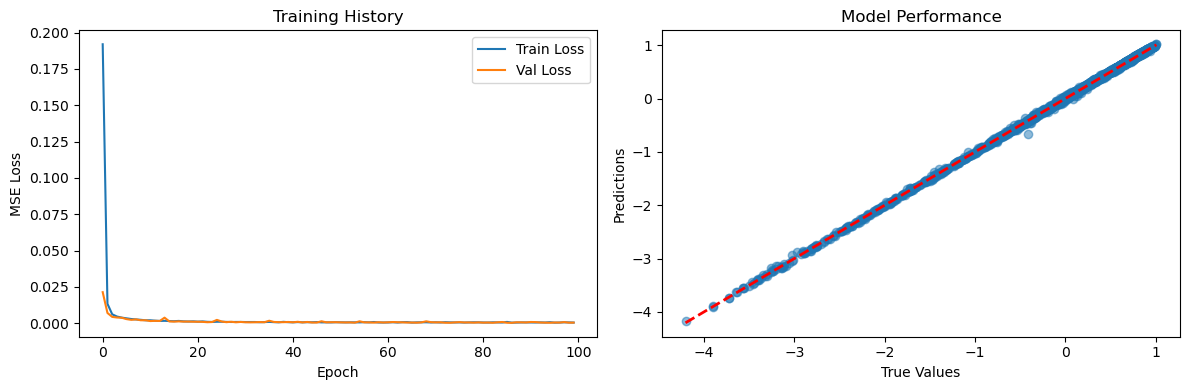

In [8]:
EPOCHS = 100
train_dataset, val_dataset, train_loader, val_loader, feature_cols, X_val, y_val, X_train, y_train = load_data(scaling=True)
model = SurrogateModel(input_dim=len(feature_cols), hidden_dims=[64])
print(f"Training model with {len(feature_cols)} input features...")
train_losses, val_losses = train_model(model, train_loader, val_loader)

# 6. Evaluation
model.eval()
with torch.no_grad():
    X_test = torch.FloatTensor(X_val.values)
    predictions = model(X_test).numpy().flatten()

plot_results(train_losses, val_losses, predictions)

In [9]:
%%timeit
model.eval()
with torch.no_grad():
    X_test = torch.FloatTensor(X_val.values)
    predictions = model(X_test).numpy().flatten()

390 μs ± 67.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [108]:
from time import time
start_time = time()
for _ in range(1000):
    model.eval()
    with torch.no_grad():
        X_test = torch.FloatTensor(X_val.values)
        predictions = model(X_test).numpy().flatten()
end_time = time()
print((end_time - start_time), 'ms')

0.3365457057952881 ms


### Conclusion for this section
- 1 hidden layer with only 64 neurons provides lower MSE and faster training **if scaled**. This is standard practice.
- This simple FFNN with only 64 hidden layers produces highly accurate results
- Execution times reduce from ~24 ms to 0.34 ms, speed up factor of about 70x. 

# Error study
The objective of this part is to better understand the error distributions within the microkinetic landscape

In [109]:
def postprocessing(predictions, y_val):
    plt.figure()
    plt.hist(np.exp(predictions) - np.exp(y_val), bins=30)
    plt.xlabel('error, mol/m2/s')
    plt.show()

    plt.figure()
    plt.plot(np.exp(predictions), np.exp(y_val), '.')
    plt.xlabel(r'predicted N$_2$O rate, mol/m2/s')
    plt.ylabel(r'IDA solved N$_2$O rate, mol/m2/s')
    plt.show()
    

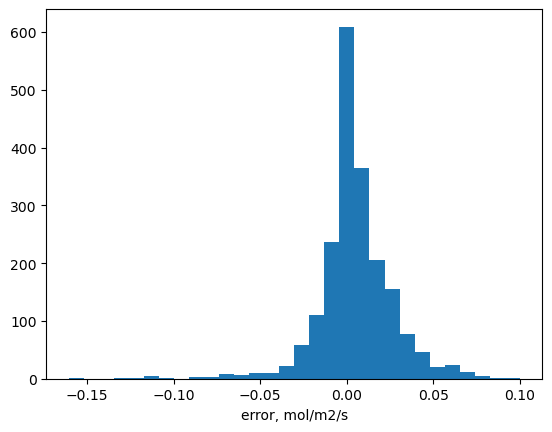

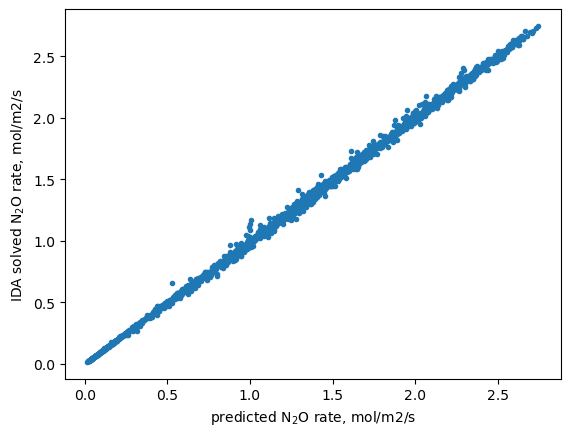

In [110]:
postprocessing(predictions, y_val)

We should consider more accurate ways to model this. We have a few options. More neurons, more hidden layers, different activation functions. 
One of the problems to be addressed is that the error rates are larger for larger reaction rates. One of the observations pointed out in my thesis is that using log scaling on the rates is effectively doing a proportional error evaluation in the training phase, meaning that errors are treated equally on the low end of the spectrum as compared to the higher end of the reaction rate spectrum. This happens due to the properties of logarithms. Using MSE penalizes larger % deviations compared to smaller ones, which is in line with our objectives.

## Network architecture study
First we'll focus on ReLU activation functions

Train T range: 500.052567768837 to 1499.8862778372106
Val T range: 500.8647911688058 to 1498.833605698965
0.0011019322451042105 0.0003558383448045687
0.0010925433530073782 0.0003484421744351687
Training model with 4 input features...
Epoch [20/100] - Train Loss: 0.000768, Val Loss: 0.000730
Epoch [40/100] - Train Loss: 0.000408, Val Loss: 0.000320
Epoch [60/100] - Train Loss: 0.000327, Val Loss: 0.000297
Epoch [80/100] - Train Loss: 0.000274, Val Loss: 0.000320
Epoch [100/100] - Train Loss: 0.000284, Val Loss: 0.001232


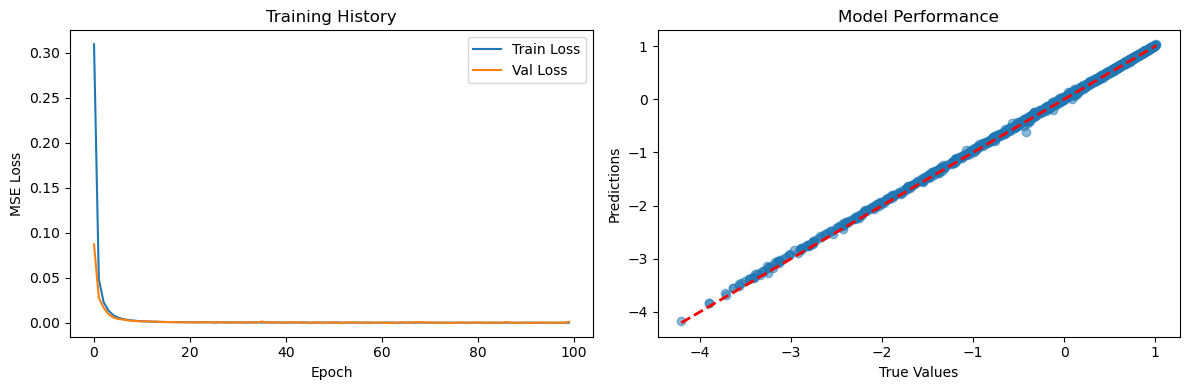

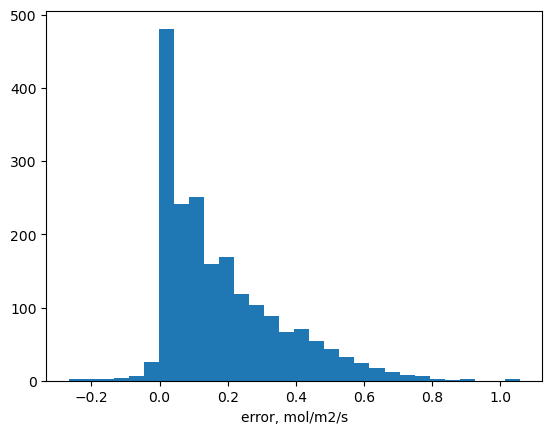

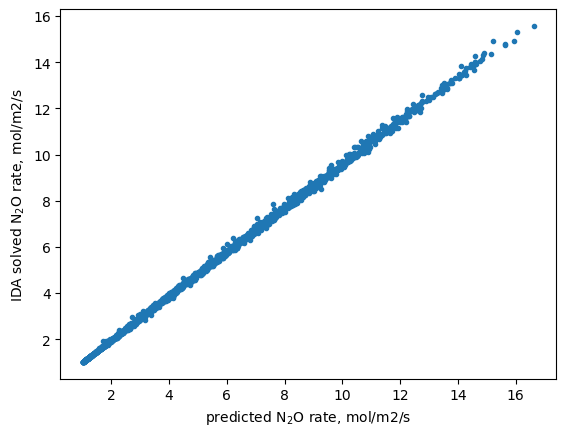

In [113]:
# Initialize and train model
train_dataset, val_dataset, train_loader, val_loader, feature_cols, X_val, y_val, X_train, y_train = load_data(scaling=True)
model = SurrogateModel(input_dim=len(feature_cols), hidden_dims=[256], activation='Relu')
print(f"Training model with {len(feature_cols)} input features...")
train_losses, val_losses = train_model(model, train_loader, val_loader, learning_rate=3e-4)

# 6. Evaluation
model.eval()
with torch.no_grad():
    X_test = torch.FloatTensor(X_val.values)
    predictions = model(X_test).numpy().flatten()

plot_results(train_losses, val_losses, predictions)
postprocessing(np.exp(predictions), np.exp(y_val))

Train T range: 500.052567768837 to 1499.8862778372106
Val T range: 500.8647911688058 to 1498.833605698965
0.0011019322451042105 0.0003558383448045687
0.0010925433530073782 0.0003484421744351687
Training model with 4 input features...
Epoch [20/100] - Train Loss: 0.001086, Val Loss: 0.000481
Epoch [40/100] - Train Loss: 0.000258, Val Loss: 0.000187
Epoch [60/100] - Train Loss: 0.000142, Val Loss: 0.000128
Epoch [80/100] - Train Loss: 0.000425, Val Loss: 0.000393
Epoch [100/100] - Train Loss: 0.000748, Val Loss: 0.000086


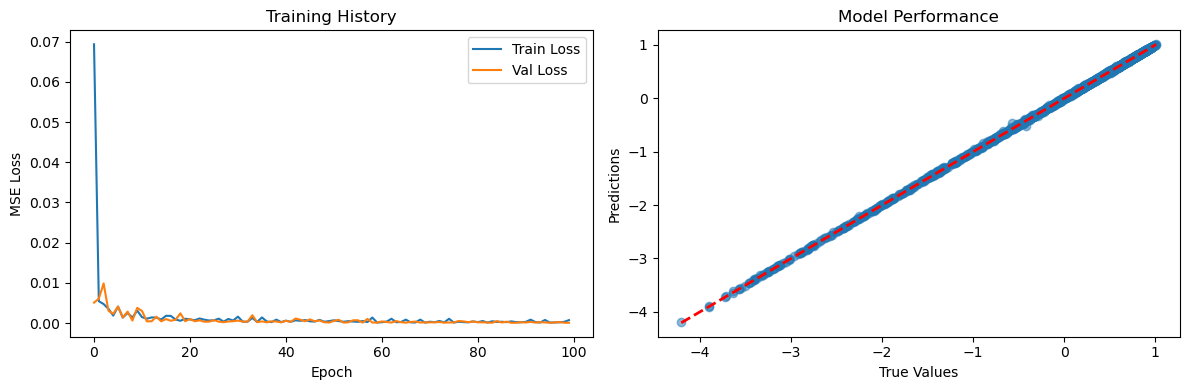

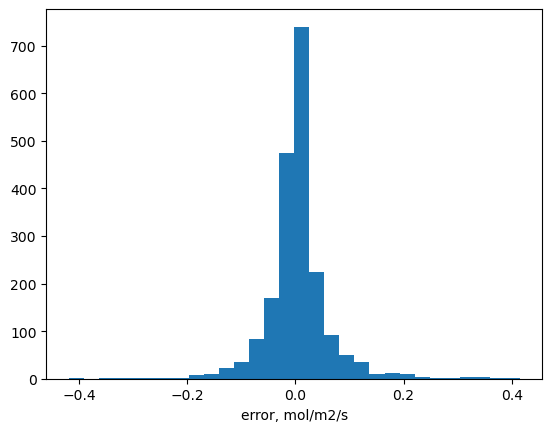

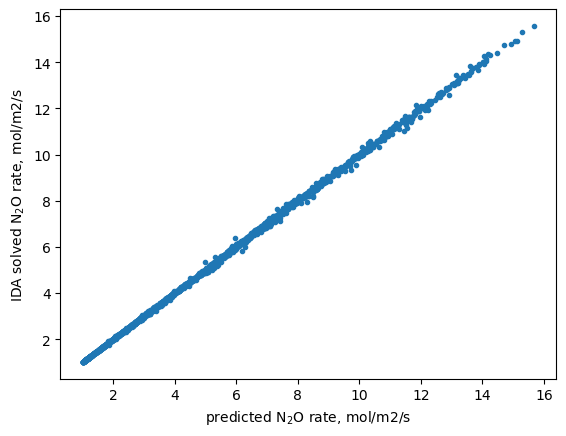

In [114]:
train_dataset, val_dataset, train_loader, val_loader, feature_cols, X_val, y_val, X_train, y_train = load_data(scaling=True)
model = SurrogateModel(input_dim=len(feature_cols), hidden_dims=[128, 128])
print(f"Training model with {len(feature_cols)} input features...")
train_losses, val_losses = train_model(model, train_loader, val_loader)

# 6. Evaluation
model.eval()
with torch.no_grad():
    X_test = torch.FloatTensor(X_val.values)
    predictions = model(X_test).numpy().flatten()

plot_results(train_losses, val_losses, predictions)
postprocessing(np.exp(predictions), np.exp(y_val))

Train T range: 500.052567768837 to 1499.8862778372106
Val T range: 500.8647911688058 to 1498.833605698965
0.0011019322451042105 0.0003558383448045687
0.0010925433530073782 0.0003484421744351687
Training model with 4 input features...
Epoch [20/100] - Train Loss: 0.002822, Val Loss: 0.000508
Epoch [40/100] - Train Loss: 0.001987, Val Loss: 0.000375
Epoch [60/100] - Train Loss: 0.001236, Val Loss: 0.001239
Epoch [80/100] - Train Loss: 0.000360, Val Loss: 0.000714
Epoch [100/100] - Train Loss: 0.000268, Val Loss: 0.000139


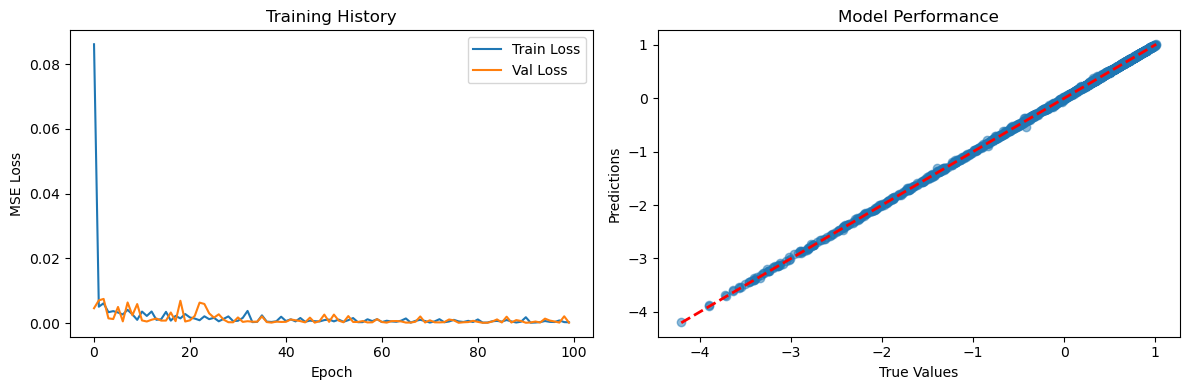

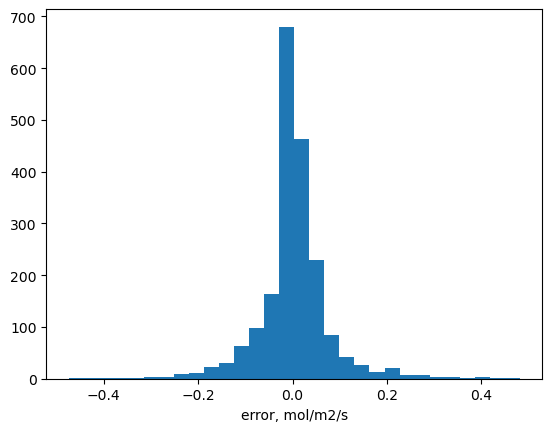

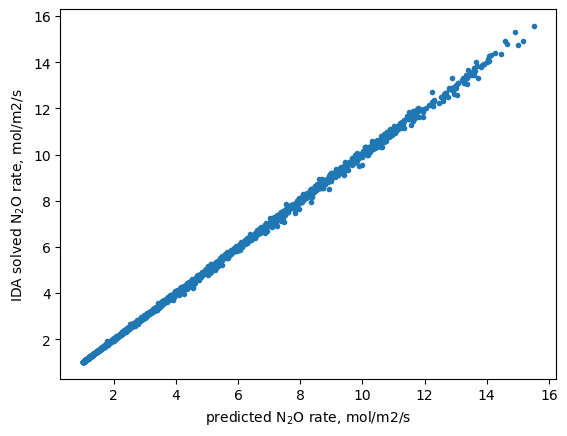

In [115]:
train_dataset, val_dataset, train_loader, val_loader, feature_cols, X_val, y_val, X_train, y_train = load_data(scaling=True)
model = SurrogateModel(input_dim=len(feature_cols), hidden_dims=[64, 64, 64, 64])
print(f"Training model with {len(feature_cols)} input features...")
train_losses, val_losses = train_model(model, train_loader, val_loader)

# 6. Evaluation
model.eval()
with torch.no_grad():
    X_test = torch.FloatTensor(X_val.values)
    predictions = model(X_test).numpy().flatten()

plot_results(train_losses, val_losses, predictions)
postprocessing(np.exp(predictions), np.exp(y_val))

They all provide similar results. We are going to try a different activation function

## SiLU activation function

Train T range: 500.052567768837 to 1499.8862778372106
Val T range: 500.8647911688058 to 1498.833605698965
0.0011019322451042105 0.0003558383448045687
0.0010925433530073782 0.0003484421744351687
Training model with 4 input features...
Epoch [20/100] - Train Loss: 0.006149, Val Loss: 0.006551
Epoch [40/100] - Train Loss: 0.003375, Val Loss: 0.003193
Epoch [60/100] - Train Loss: 0.002295, Val Loss: 0.001812
Epoch [80/100] - Train Loss: 0.001725, Val Loss: 0.001639
Epoch [100/100] - Train Loss: 0.001500, Val Loss: 0.001393


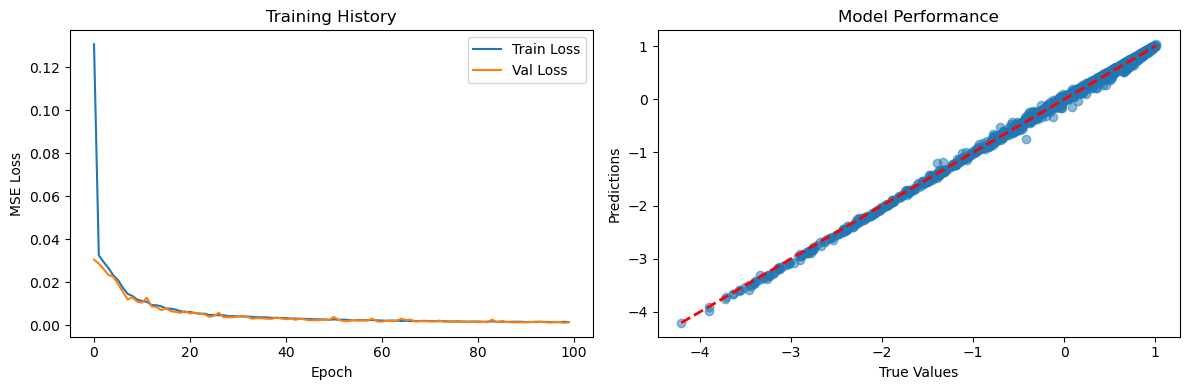

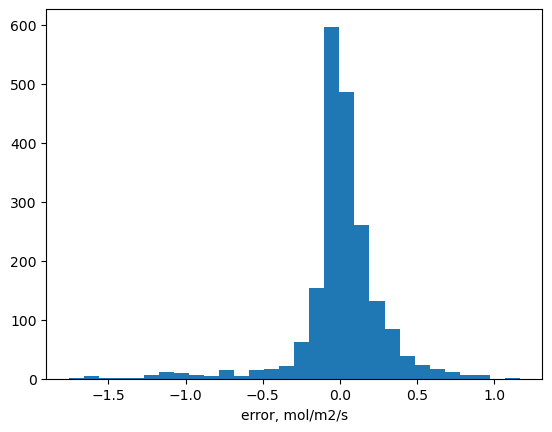

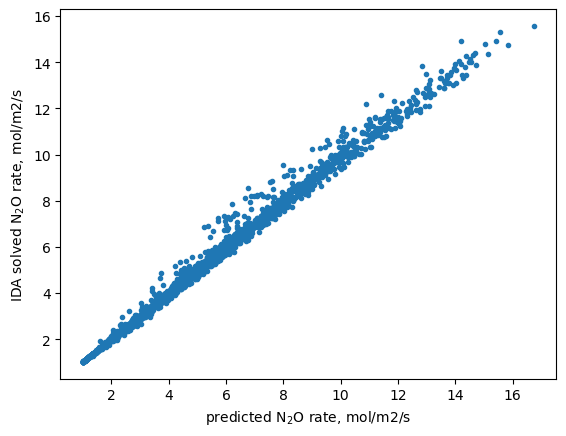

In [116]:
EPOCHS=100
train_dataset, val_dataset, train_loader, val_loader, feature_cols, X_val, y_val, X_train, y_train = load_data(scaling=True)
model = SurrogateModel(input_dim=len(feature_cols), hidden_dims=[256], activation='SiLU')
print(f"Training model with {len(feature_cols)} input features...")
train_losses, val_losses = train_model(model, train_loader, val_loader)

# 6. Evaluation
model.eval()
with torch.no_grad():
    X_test = torch.FloatTensor(X_val.values)
    predictions = model(X_test).numpy().flatten()

plot_results(train_losses, val_losses, predictions)
postprocessing(np.exp(predictions), np.exp(y_val))

Train T range: 500.052567768837 to 1499.8862778372106
Val T range: 500.8647911688058 to 1498.833605698965
0.0011019322451042105 0.0003558383448045687
0.0010925433530073782 0.0003484421744351687
Training model with 4 input features...
Epoch [20/100] - Train Loss: 0.001028, Val Loss: 0.000445
Epoch [40/100] - Train Loss: 0.000409, Val Loss: 0.000383
Epoch [60/100] - Train Loss: 0.000668, Val Loss: 0.000410
Epoch [80/100] - Train Loss: 0.000302, Val Loss: 0.000330
Epoch [100/100] - Train Loss: 0.000469, Val Loss: 0.000180


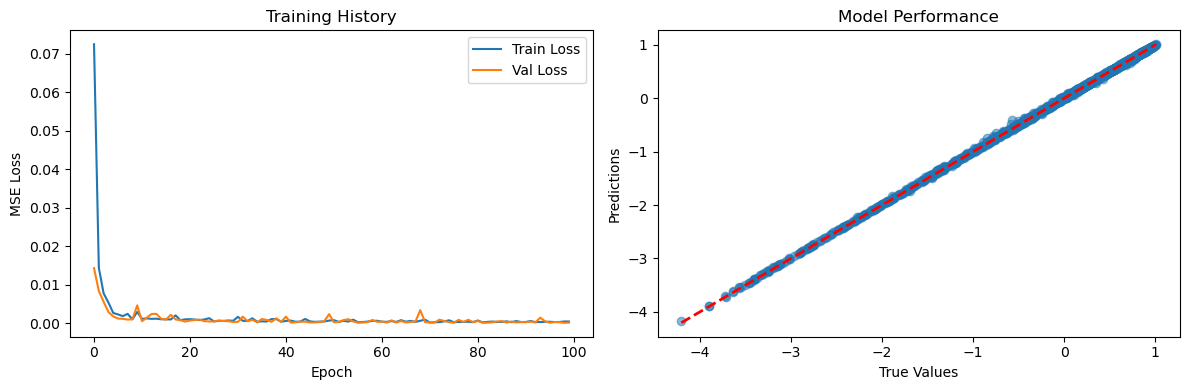

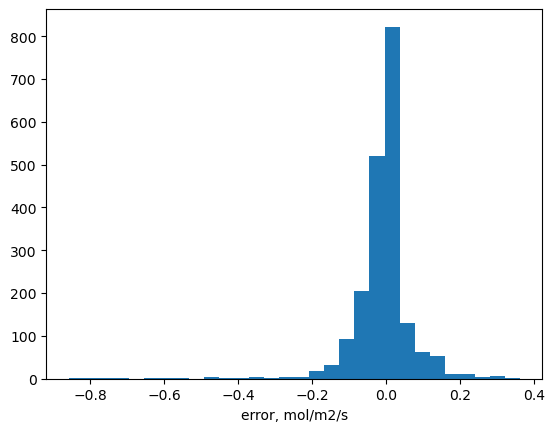

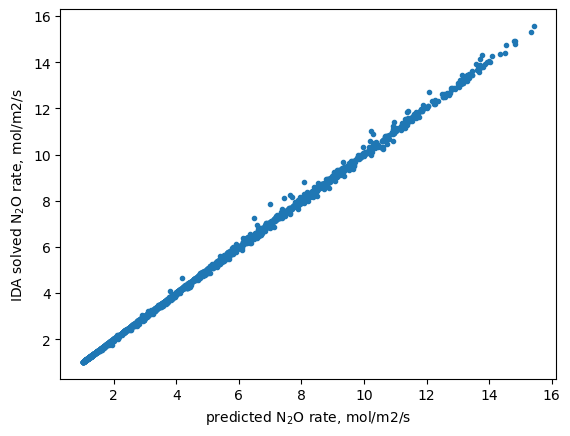

In [118]:
EPOCHS=100
train_dataset, val_dataset, train_loader, val_loader, feature_cols, X_val, y_val, X_train, y_train = load_data(scaling=True)
model = SurrogateModel(input_dim=len(feature_cols), hidden_dims=[128,128], activation='SiLU')
print(f"Training model with {len(feature_cols)} input features...")
train_losses, val_losses = train_model(model, train_loader, val_loader)

# 6. Evaluation
model.eval()
with torch.no_grad():
    X_test = torch.FloatTensor(X_val.values)
    predictions = model(X_test).numpy().flatten()

plot_results(train_losses, val_losses, predictions)
postprocessing(np.exp(predictions), np.exp(y_val))

Train T range: 500.052567768837 to 1499.8862778372106
Val T range: 500.8647911688058 to 1498.833605698965
0.0011019322451042105 0.0003558383448045687
0.0010925433530073782 0.0003484421744351687
Training model with 4 input features...
Epoch [20/100] - Train Loss: 0.000938, Val Loss: 0.000461
Epoch [40/100] - Train Loss: 0.001628, Val Loss: 0.001242
Epoch [60/100] - Train Loss: 0.000866, Val Loss: 0.000225
Epoch [80/100] - Train Loss: 0.000355, Val Loss: 0.001173
Epoch [100/100] - Train Loss: 0.000106, Val Loss: 0.000063


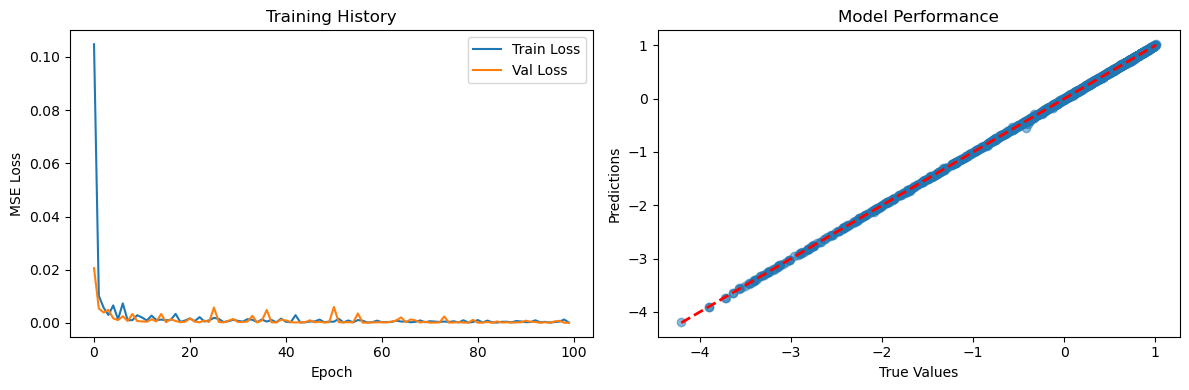

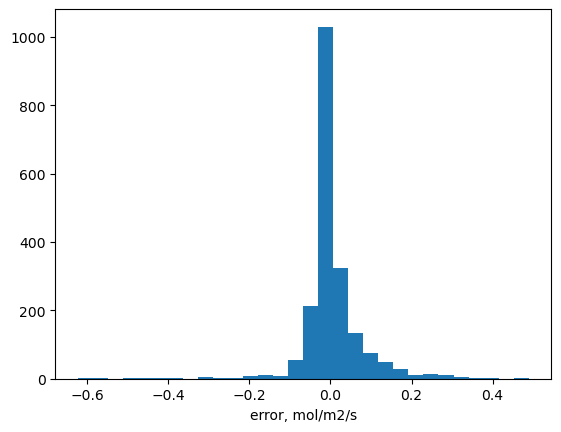

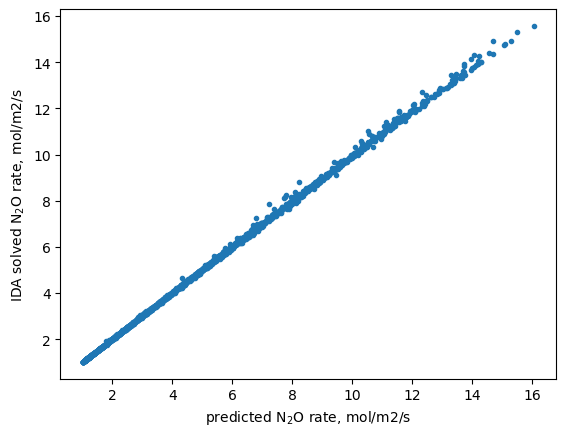

In [119]:
EPOCHS=100
train_dataset, val_dataset, train_loader, val_loader, feature_cols, X_val, y_val, X_train, y_train = load_data(scaling=True)
model = SurrogateModel(input_dim=len(feature_cols), hidden_dims=[64,64,64,64], activation='SiLU')
print(f"Training model with {len(feature_cols)} input features...")
train_losses, val_losses = train_model(model, train_loader, val_loader)

# 6. Evaluation
model.eval()
with torch.no_grad():
    X_test = torch.FloatTensor(X_val.values)
    predictions = model(X_test).numpy().flatten()

plot_results(train_losses, val_losses, predictions)
postprocessing(np.exp(predictions), np.exp(y_val))

# Extrapolation to higher temperatures
This shows that this networks is good at doing interpolation which was our main objective, but it fails catastrophically at extrapolation. This is an indication that the network is not learning the physical phenomena of the problem.

Train T range: 500.052567768837 to 1499.8862778372106
Val T range: 500.8647911688058 to 1498.833605698965
0.0014714613874432618 0.00025243782502908747
0.0010925433530073782 0.0003484421744351687
Training model with 4 input features...
Epoch [20/100] - Train Loss: 0.001185, Val Loss: 0.010853
Epoch [40/100] - Train Loss: 0.000294, Val Loss: 0.008056
Epoch [60/100] - Train Loss: 0.000133, Val Loss: 0.008034
Epoch [80/100] - Train Loss: 0.000529, Val Loss: 0.008235
Epoch [100/100] - Train Loss: 0.000761, Val Loss: 0.008848


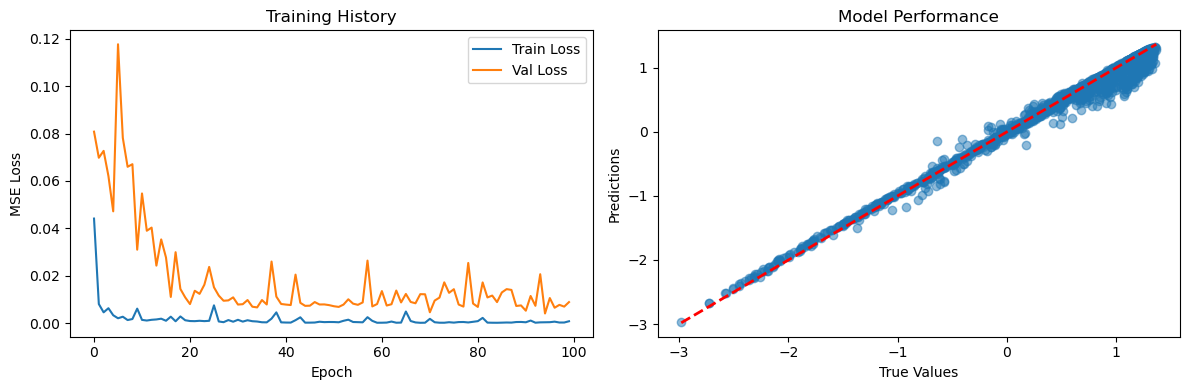

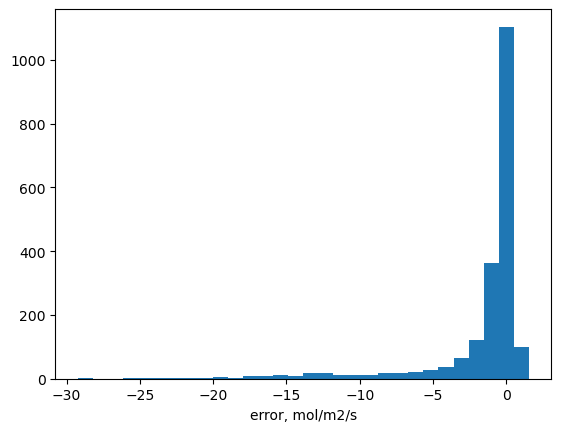

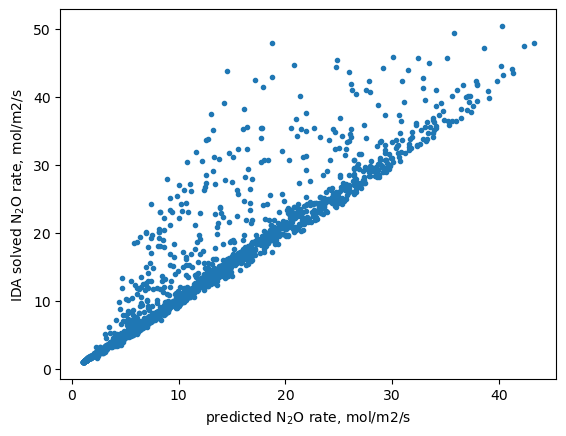

In [122]:
EPOCHS=100
train_dataset, val_dataset, train_loader, val_loader, feature_cols, X_val, y_val, X_train, y_train = load_data(scaling=True, max_train_temp=900)
model = SurrogateModel(input_dim=len(feature_cols), hidden_dims=[256,256], activation='SiLU')
print(f"Training model with {len(feature_cols)} input features...")
train_losses, val_losses = train_model(model, train_loader, val_loader)

# 6. Evaluation
model.eval()
with torch.no_grad():
    X_test = torch.FloatTensor(X_val.values)
    predictions = model(X_test).numpy().flatten()

plot_results(train_losses, val_losses, predictions)
postprocessing(np.exp(predictions), np.exp(y_val))

Train T range: 500.052567768837 to 1499.8862778372106
Val T range: 500.8647911688058 to 1498.833605698965
0.0014714613874432618 0.00025243782502908747
0.0010925433530073782 0.0003484421744351687
Training model with 4 input features...
Epoch [20/300] - Train Loss: 0.000385, Val Loss: 0.019125
Epoch [40/300] - Train Loss: 0.000918, Val Loss: 0.018930
Epoch [60/300] - Train Loss: 0.000705, Val Loss: 0.006405
Epoch [80/300] - Train Loss: 0.000323, Val Loss: 0.007500
Epoch [100/300] - Train Loss: 0.000165, Val Loss: 0.005878
Epoch [120/300] - Train Loss: 0.001144, Val Loss: 0.006657
Epoch [140/300] - Train Loss: 0.002394, Val Loss: 0.017954
Epoch [160/300] - Train Loss: 0.000209, Val Loss: 0.005715
Epoch [180/300] - Train Loss: 0.000489, Val Loss: 0.006240
Epoch [200/300] - Train Loss: 0.000128, Val Loss: 0.006246
Epoch [220/300] - Train Loss: 0.000228, Val Loss: 0.004015
Epoch [240/300] - Train Loss: 0.000415, Val Loss: 0.005232
Epoch [260/300] - Train Loss: 0.000133, Val Loss: 0.004148
Ep

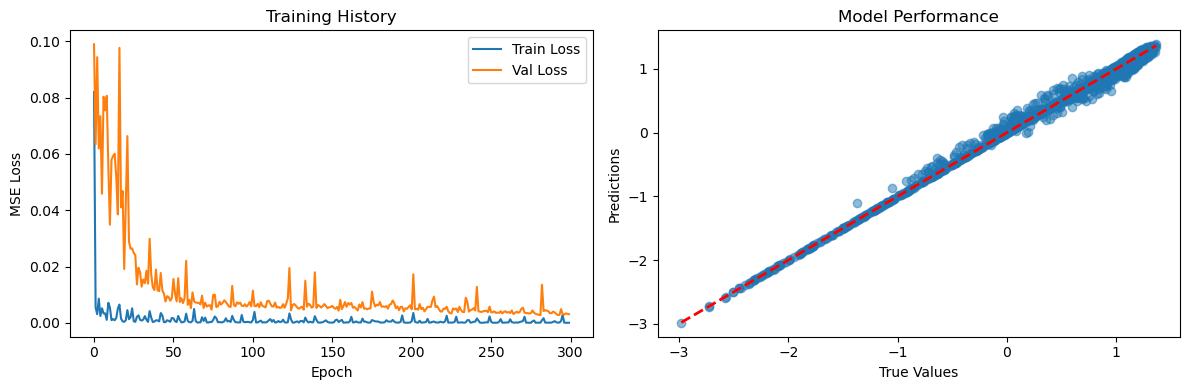

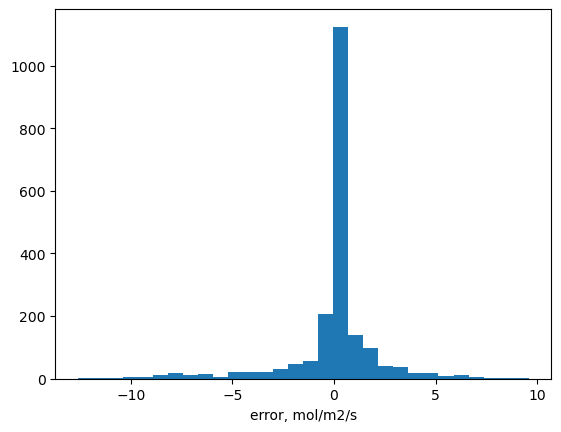

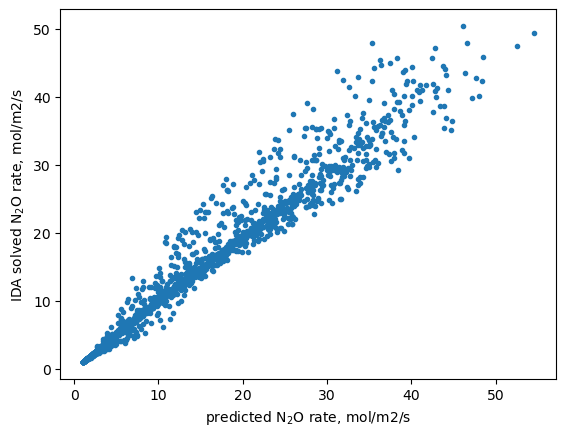

In [124]:
EPOCHS=300
train_dataset, val_dataset, train_loader, val_loader, feature_cols, X_val, y_val, X_train, y_train = load_data(scaling=True, max_train_temp=900)
model = SurrogateModel(input_dim=len(feature_cols), hidden_dims=[128,128,128,128], activation='SiLU')
print(f"Training model with {len(feature_cols)} input features...")
train_losses, val_losses = train_model(model, train_loader, val_loader)

# 6. Evaluation
model.eval()
with torch.no_grad():
    X_test = torch.FloatTensor(X_val.values)
    predictions = model(X_test).numpy().flatten()

plot_results(train_losses, val_losses, predictions)
postprocessing(np.exp(predictions), np.exp(y_val))

## Controlled model experiments (run manually)

If starting with a fresh kernel, first run the existing imports and definitions above (including `ReactionDataset` and `load_data`). Then run the setup cell once, followed by **one experiment cell at a time**. They share a fixed random train/validation split, scaled data, seed, batch order, optimizer, and corrected training loop (one optimizer update per batch, with gradient clipping before it). Validation MSE is in standardized log-rate units. These experiments use a random split, so they measure interpolation rather than temperature extrapolation. They are comparisons, not guarantees that deeper or regularized models will perform better.

To try another seed, change `EXPERIMENT_SEED` in the setup cell, rerun setup, and then rerun the experiment cells. Results and best models are kept in `EXPERIMENT_RESULTS` and `EXPERIMENT_MODELS`.

In [10]:
import copy

EXPERIMENT_SEED = 2026
EXPERIMENT_EPOCHS = 300
EXPERIMENT_PATIENCE = 40
EXPERIMENT_BATCH_SIZE = 32

torch.manual_seed(EXPERIMENT_SEED)
(
    EXP_TRAIN_DATASET, EXP_VAL_DATASET, _, EXP_VAL_LOADER,
    EXP_FEATURE_COLS, EXP_X_VAL, EXP_Y_VAL, _, _,
) = load_data(scaling=True, random_state=1, batch_size=EXPERIMENT_BATCH_SIZE)

EXPERIMENT_RESULTS = {}
EXPERIMENT_MODELS = {}

class ExperimentNet(nn.Module):
    def __init__(self, input_dim, width=64, depth=2, activation="ReLU",
                 dropout=0.0, residual=False, init="default"):
        super().__init__()
        activations = {"ReLU": nn.ReLU, "SiLU": nn.SiLU, "Tanh": nn.Tanh}
        if activation not in activations:
            raise ValueError(f"Unsupported activation: {activation}")
        if width < 1 or depth < 1:
            raise ValueError("width and depth must be positive")
        if not 0.0 <= dropout < 1.0:
            raise ValueError("dropout must be in [0, 1)")
        if init not in {"default", "kaiming", "xavier"}:
            raise ValueError(f"Unsupported initialization: {init}")

        self.activation = activations[activation]()
        self.residual = residual
        self.dropout = nn.Dropout(dropout) if dropout else nn.Identity()
        self.input_layer = nn.Linear(input_dim, width)
        self.hidden_layers = nn.ModuleList(
            nn.Linear(width, width) for _ in range(depth - 1)
        )
        self.residual_layers = nn.ModuleList(
            nn.Linear(width, width) for _ in range(depth - 1)
        ) if residual else nn.ModuleList()
        self.output_layer = nn.Linear(width, 1)

        if init != "default":
            for name, layer in self.named_modules():
                if isinstance(layer, nn.Linear) and name != "output_layer":
                    if init == "kaiming":
                        nn.init.kaiming_uniform_(layer.weight, nonlinearity="relu")
                    else:
                        nn.init.xavier_uniform_(layer.weight)
                    nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = self.dropout(self.activation(self.input_layer(x)))
        for index, layer in enumerate(self.hidden_layers):
            update = self.activation(layer(x))
            if self.residual:
                update = self.residual_layers[index](self.dropout(update))
                x = self.activation(x + update)
            else:
                x = self.dropout(update)
        return self.output_layer(x)

def run_experiment(name, **model_kwargs):
    torch.manual_seed(EXPERIMENT_SEED)
    model = ExperimentNet(
        input_dim=len(EXP_FEATURE_COLS), **model_kwargs
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    train_generator = torch.Generator().manual_seed(EXPERIMENT_SEED)
    train_loader = DataLoader(
        EXP_TRAIN_DATASET, batch_size=EXPERIMENT_BATCH_SIZE,
        shuffle=True, generator=train_generator,
    )
    val_loader = DataLoader(
        EXP_VAL_DATASET, batch_size=EXPERIMENT_BATCH_SIZE, shuffle=False,
    )

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0
    best_train_loss = float("inf")

    for epoch in range(EXPERIMENT_EPOCHS):
        model.train()
        train_total = 0.0
        train_count = 0
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            predictions = model(x_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_total += loss.item() * len(x_batch)
            train_count += len(x_batch)
        train_loss = train_total / train_count

        model.eval()
        val_total = 0.0
        val_count = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                val_loss = criterion(model(x_batch), y_batch)
                val_total += val_loss.item() * len(x_batch)
                val_count += len(x_batch)
        val_loss = val_total / val_count

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_train_loss = train_loss
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= EXPERIMENT_PATIENCE:
                break

    if best_state is None:
        raise RuntimeError("Training did not produce a valid checkpoint")
    model.load_state_dict(best_state)
    model.eval()
    EXPERIMENT_MODELS[name] = model
    EXPERIMENT_RESULTS[name] = {
        "best_epoch": best_epoch,
        "train_mse": best_train_loss,
        "val_mse": best_val_loss,
    }
    print(f"{name}: best epoch {best_epoch}, "
          f"train MSE {best_train_loss:.6f}, "
          f"validation MSE {best_val_loss:.6f}")
    print(pd.DataFrame.from_dict(EXPERIMENT_RESULTS, orient="index")
          .sort_values("val_mse").to_string())
    return model

Train T range: 500.052567768837 to 1499.8862778372106
Val T range: 500.8647911688058 to 1498.833605698965


In [11]:
# Test 1: corrected two-layer, 64-wide baseline.
baseline_model = run_experiment("baseline-2x64", width=64, depth=2)

baseline-2x64: best epoch 112, train MSE 0.000077, validation MSE 0.000064
               best_epoch  train_mse   val_mse
baseline-2x64         112   0.000077  0.000064


In [12]:
# Test 2: deeper plain MLP; only depth differs from the baseline.
deeper_model = run_experiment("plain-4x64", width=64, depth=4)

plain-4x64: best epoch 149, train MSE 0.000058, validation MSE 0.000038
               best_epoch  train_mse   val_mse
plain-4x64            149   0.000058  0.000038
baseline-2x64         112   0.000077  0.000064


In [13]:
# Test 3: residual MLP with the deeper model's width and depth.
residual_model = run_experiment(
    "residual-4x64", width=64, depth=4, residual=True
)

residual-4x64: best epoch 123, train MSE 0.000092, validation MSE 0.000033
               best_epoch  train_mse   val_mse
residual-4x64         123   0.000092  0.000033
plain-4x64            149   0.000058  0.000038
baseline-2x64         112   0.000077  0.000064


In [14]:
# Test 4: modest dropout; compare with baseline-2x64.
dropout_model = run_experiment(
    "dropout-2x64-p01", width=64, depth=2, dropout=0.1
)

dropout-2x64-p01: best epoch 40, train MSE 0.008897, validation MSE 0.000917
                  best_epoch  train_mse   val_mse
residual-4x64            123   0.000092  0.000033
plain-4x64               149   0.000058  0.000038
baseline-2x64            112   0.000077  0.000064
dropout-2x64-p01          40   0.008897  0.000917


In [16]:
# Test 5: explicit Kaiming/He initialization of hidden layers.
kaiming_model = run_experiment(
    "kaiming-2x64", width=64, depth=2, init="kaiming"
)

kaiming-2x64: best epoch 264, train MSE 0.000110, validation MSE 0.000069
                  best_epoch  train_mse   val_mse
residual-4x64            123   0.000092  0.000033
plain-4x64               149   0.000058  0.000038
baseline-2x64            112   0.000077  0.000064
kaiming-2x64             264   0.000110  0.000069
dropout-2x64-p01          40   0.008897  0.000917


In [17]:
# Test 6: Xavier initialization; same architecture as the He test.
xavier_model = run_experiment(
    "xavier-2x64", width=64, depth=2, init="xavier"
)

xavier-2x64: best epoch 214, train MSE 0.000093, validation MSE 0.000043
                  best_epoch  train_mse   val_mse
residual-4x64            123   0.000092  0.000033
plain-4x64               149   0.000058  0.000038
xavier-2x64              214   0.000093  0.000043
baseline-2x64            112   0.000077  0.000064
kaiming-2x64             264   0.000110  0.000069
dropout-2x64-p01          40   0.008897  0.000917


## Raw-input and signed-rate tests

Run the imports, model definitions, and earlier experiment setup first, then run the setup below once. These experiments use raw temperature and mole fractions, standardized using training-set statistics only. No feature logs or `1/T` are applied. Compare predicting the signed rate directly with an optional `asinh` target transform, which handles negative, zero, and positive rates. Compare physical-unit RMSE/MAE; target-space MSE values are not directly comparable across transforms.

In [18]:
from torch.utils.data import TensorDataset
from sklearn.model_selection import train_test_split

signed_df = pd.read_csv(CSV_PATH)[['T', 'xNH3', 'xO2', 'xNO', 'rN2O']]
signed_df = signed_df.sample(10000, random_state=1)
signed_train_idx, signed_val_idx = train_test_split(
    signed_df.index, test_size=TEST_SPLIT, random_state=1
)
signed_train = signed_df.loc[signed_train_idx]
signed_val = signed_df.loc[signed_val_idx]
SIGNED_FEATURES = ['T', 'xNH3', 'xO2', 'xNO']
signed_x_train = signed_train[SIGNED_FEATURES].to_numpy(dtype=np.float64)
signed_x_val = signed_val[SIGNED_FEATURES].to_numpy(dtype=np.float64)
signed_y_train = signed_train['rN2O'].to_numpy(dtype=np.float64)
signed_y_val = signed_val['rN2O'].to_numpy(dtype=np.float64)
if not all(np.isfinite(a).all() for a in
           (signed_x_train, signed_x_val, signed_y_train, signed_y_val)):
    raise ValueError('Raw features and rates must all be finite')

signed_x_mean = signed_x_train.mean(axis=0)
signed_x_std = signed_x_train.std(axis=0)
if np.any(signed_x_std == 0):
    raise ValueError('A raw input feature has zero training-set variance')
signed_x_train = (signed_x_train - signed_x_mean) / signed_x_std
signed_x_val = (signed_x_val - signed_x_mean) / signed_x_std
SIGNED_RATE_SCALE = np.median(np.abs(signed_y_train))
if not np.isfinite(SIGNED_RATE_SCALE) or SIGNED_RATE_SCALE <= 0:
    raise ValueError('Cannot use asinh: training rates have no positive magnitude')
SIGNED_RATE_RESULTS = {}
SIGNED_RATE_MODELS = {}
print(f'Train rates: {(signed_y_train < 0).sum()} negative, '
      f'{(signed_y_train == 0).sum()} zero, {(signed_y_train > 0).sum()} positive')
print(f'Validation rates: {(signed_y_val < 0).sum()} negative, '
      f'{(signed_y_val == 0).sum()} zero, {(signed_y_val > 0).sum()} positive')

def run_signed_rate_experiment(name, target_transform='raw'):
    if target_transform == 'raw':
        y_train_transformed, y_val_transformed = signed_y_train, signed_y_val
    elif target_transform == 'asinh':
        y_train_transformed = np.arcsinh(signed_y_train / SIGNED_RATE_SCALE)
        y_val_transformed = np.arcsinh(signed_y_val / SIGNED_RATE_SCALE)
    else:
        raise ValueError("target_transform must be 'raw' or 'asinh'")

    y_mean, y_std = y_train_transformed.mean(), y_train_transformed.std()
    if not np.isfinite(y_std) or y_std == 0:
        raise ValueError('Transformed training rates have zero or invalid variance')
    y_train_scaled = (y_train_transformed - y_mean) / y_std
    y_val_scaled = (y_val_transformed - y_mean) / y_std
    train_data = TensorDataset(
        torch.tensor(signed_x_train, dtype=torch.float32),
        torch.tensor(y_train_scaled, dtype=torch.float32).reshape(-1, 1),
    )
    val_data = TensorDataset(
        torch.tensor(signed_x_val, dtype=torch.float32),
        torch.tensor(y_val_scaled, dtype=torch.float32).reshape(-1, 1),
    )
    torch.manual_seed(EXPERIMENT_SEED)
    model = ExperimentNet(input_dim=len(SIGNED_FEATURES), width=64, depth=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    train_loader = DataLoader(
        train_data, batch_size=EXPERIMENT_BATCH_SIZE, shuffle=True,
        generator=torch.Generator().manual_seed(EXPERIMENT_SEED),
    )
    val_loader = DataLoader(val_data, batch_size=EXPERIMENT_BATCH_SIZE)
    best_loss, best_state, best_epoch, wait = float('inf'), None, 0, 0

    for epoch in range(EXPERIMENT_EPOCHS):
        model.train()
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x_batch), y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        model.eval()
        val_total, val_count = 0.0, 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                batch_loss = criterion(model(x_batch), y_batch)
                val_total += batch_loss.item() * len(x_batch)
                val_count += len(x_batch)
        val_loss = val_total / val_count
        if val_loss < best_loss - 1e-6:
            best_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch, wait = epoch + 1, 0
        else:
            wait += 1
            if wait >= EXPERIMENT_PATIENCE:
                break

    if best_state is None:
        raise RuntimeError('Training did not produce a valid checkpoint')
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        x_val_tensor = torch.tensor(signed_x_val, dtype=torch.float32)
        prediction_scaled = model(x_val_tensor).squeeze(1).numpy()
    prediction_transformed = prediction_scaled * y_std + y_mean
    if target_transform == 'asinh':
        with np.errstate(over='raise', invalid='raise'):
            prediction_rate = SIGNED_RATE_SCALE * np.sinh(prediction_transformed)
    else:
        prediction_rate = prediction_transformed
    if not np.isfinite(prediction_rate).all():
        raise FloatingPointError('Predicted rates are non-finite')
    error = prediction_rate - signed_y_val
    metrics = {
        'best_epoch': best_epoch,
        'target_space_val_mse': best_loss,
        'rate_rmse': float(np.sqrt(np.mean(error ** 2))),
        'rate_mae': float(np.mean(np.abs(error))),
        'sign_accuracy': float(np.mean(np.sign(prediction_rate) == np.sign(signed_y_val))),
    }
    SIGNED_RATE_MODELS[name] = model
    SIGNED_RATE_RESULTS[name] = metrics
    print(pd.DataFrame.from_dict(SIGNED_RATE_RESULTS, orient='index').to_string())
    return model, prediction_rate

Train rates: 0 negative, 0 zero, 8000 positive
Validation rates: 0 negative, 0 zero, 2000 positive


In [19]:
# Test 1: raw inputs; predict signed rates directly (no rate log).
raw_rate_model, raw_rate_predictions = run_signed_rate_experiment(
    'raw-inputs_raw-rate', target_transform='raw'
)

                     best_epoch  target_space_val_mse  rate_rmse  rate_mae  sign_accuracy
raw-inputs_raw-rate         210              0.000316   0.084414  0.058514         0.8875


In [20]:
# Test 2: same raw inputs; compare signed asinh target handling.
asinh_rate_model, asinh_rate_predictions = run_signed_rate_experiment(
    'raw-inputs_asinh-rate', target_transform='asinh'
)

                       best_epoch  target_space_val_mse  rate_rmse  rate_mae  sign_accuracy
raw-inputs_raw-rate           210              0.000316   0.084414  0.058514         0.8875
raw-inputs_asinh-rate         275              0.000473   0.093950  0.058907         0.9425


## Hand-crafted kinetic inputs, signed raw-rate target

Run after the earlier signed-rate setup. This test changes the inputs to `1/T` and `log(x)` for the concentrations, while keeping the rate itself unlogged and signed. It uses the same train/validation rows and neural-network/training settings as the raw-input signed-rate tests. Compare `rate_rmse` and `rate_mae` with the prior `raw-inputs_raw-rate` row in `SIGNED_RATE_RESULTS`.

In [21]:
transformed_feature_names = ['1/T', 'log(xNH3)', 'log(xO2)', 'log(xNO)']

if (signed_train['T'].le(0).any() or signed_val['T'].le(0).any()
        or not np.isfinite(signed_train['T']).all()
        or not np.isfinite(signed_val['T']).all()):
    raise ValueError('Temperature must be finite and strictly positive for 1/T')

concentration_cols = ['xNH3', 'xO2', 'xNO']
for split_name, split_df in [('training', signed_train), ('validation', signed_val)]:
    invalid_counts = split_df[concentration_cols].le(0).sum()
    if invalid_counts.any():
        raise ValueError(
            f'{split_name} concentrations must be strictly positive for logs; '
            f'invalid counts: {invalid_counts[invalid_counts > 0].to_dict()}'
        )

arrhenius_x_train = np.column_stack([
    1.0 / signed_train['T'].to_numpy(dtype=np.float64),
    *[np.log(signed_train[col].to_numpy(dtype=np.float64)) for col in concentration_cols],
])
arrhenius_x_val = np.column_stack([
    1.0 / signed_val['T'].to_numpy(dtype=np.float64),
    *[np.log(signed_val[col].to_numpy(dtype=np.float64)) for col in concentration_cols],
])
if not np.isfinite(arrhenius_x_train).all() or not np.isfinite(arrhenius_x_val).all():
    raise FloatingPointError('Transformed inputs contain non-finite values')

arrhenius_x_mean = arrhenius_x_train.mean(axis=0)
arrhenius_x_std = arrhenius_x_train.std(axis=0)
if np.any(arrhenius_x_std == 0):
    raise ValueError('A transformed input has zero training-set variance')
arrhenius_x_train = (arrhenius_x_train - arrhenius_x_mean) / arrhenius_x_std
arrhenius_x_val = (arrhenius_x_val - arrhenius_x_mean) / arrhenius_x_std

original_signed_inputs = (signed_x_train, signed_x_val, SIGNED_FEATURES)
try:
    signed_x_train, signed_x_val = arrhenius_x_train, arrhenius_x_val
    SIGNED_FEATURES = transformed_feature_names
    arrhenius_input_model, arrhenius_input_predictions = run_signed_rate_experiment(
        '1overT_log-concentrations_raw-rate', target_transform='raw'
    )
finally:
    signed_x_train, signed_x_val, SIGNED_FEATURES = original_signed_inputs

                                    best_epoch  target_space_val_mse  rate_rmse  rate_mae  sign_accuracy
raw-inputs_raw-rate                        210              0.000316   0.084414  0.058514         0.8875
raw-inputs_asinh-rate                      275              0.000473   0.093950  0.058907         0.9425
1overT_log-concentrations_raw-rate         135              0.000138   0.055680  0.038668         0.9845


## Increasing model capacity (rate remains untransformed)

These tests build on the `1/T` and log-concentration inputs above. The target is always the original `rN2O` value: it is not logged, transformed, or standardized. All errors are reported in rate units. Run the setup/helper cell, then run the architecture cells one at a time. Compare training RMSE with validation RMSE: if training error falls while validation error rises, added complexity is overfitting rather than helping. Results use one fixed split and seed; rerun promising models with several seeds before choosing a winner.

In [22]:
COMPLEXITY_EPOCHS = 500
COMPLEXITY_PATIENCE = 50
COMPLEXITY_SEED = EXPERIMENT_SEED
complexity_x_train = torch.tensor(arrhenius_x_train, dtype=torch.float32)
complexity_x_val = torch.tensor(arrhenius_x_val, dtype=torch.float32)
complexity_y_train = torch.tensor(signed_y_train, dtype=torch.float32).reshape(-1, 1)
complexity_y_val = torch.tensor(signed_y_val, dtype=torch.float32).reshape(-1, 1)
COMPLEXITY_RESULTS = {}
COMPLEXITY_MODELS = {}

def run_complexity_test(name, width=64, depth=2, residual=False, dropout=0.0):
    torch.manual_seed(COMPLEXITY_SEED)
    model = ExperimentNet(
        input_dim=complexity_x_train.shape[1], width=width, depth=depth,
        residual=residual, dropout=dropout,
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    train_data = TensorDataset(complexity_x_train, complexity_y_train)
    val_data = TensorDataset(complexity_x_val, complexity_y_val)
    train_loader = DataLoader(
        train_data, batch_size=EXPERIMENT_BATCH_SIZE, shuffle=True,
        generator=torch.Generator().manual_seed(COMPLEXITY_SEED),
    )
    val_loader = DataLoader(val_data, batch_size=EXPERIMENT_BATCH_SIZE)

    best_val_mse, best_state, best_epoch, wait = float('inf'), None, 0, 0
    for epoch in range(COMPLEXITY_EPOCHS):
        model.train()
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x_batch), y_batch)
            if not torch.isfinite(loss):
                raise FloatingPointError(f'{name}: non-finite training loss at epoch {epoch + 1}')
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        val_sum, val_count = 0.0, 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                batch_loss = criterion(model(x_batch), y_batch)
                if not torch.isfinite(batch_loss):
                    raise FloatingPointError(f'{name}: non-finite validation loss at epoch {epoch + 1}')
                val_sum += batch_loss.item() * len(x_batch)
                val_count += len(x_batch)
        val_mse = val_sum / val_count
        if val_mse < best_val_mse - 1e-10:
            best_val_mse = val_mse
            best_state = copy.deepcopy(model.state_dict())
            best_epoch, wait = epoch + 1, 0
        else:
            wait += 1
            if wait >= COMPLEXITY_PATIENCE:
                break

    if best_state is None:
        raise RuntimeError(f'{name}: training produced no valid checkpoint')
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        train_pred = model(complexity_x_train).squeeze(1).numpy()
        val_pred = model(complexity_x_val).squeeze(1).numpy()
    if not np.isfinite(train_pred).all() or not np.isfinite(val_pred).all():
        raise FloatingPointError(f'{name}: model produced non-finite rate predictions')

    train_true = complexity_y_train.squeeze(1).numpy()
    val_true = complexity_y_val.squeeze(1).numpy()
    train_rmse = float(np.sqrt(np.mean((train_pred - train_true) ** 2)))
    val_rmse = float(np.sqrt(np.mean((val_pred - val_true) ** 2)))
    val_ss_tot = np.sum((val_true - val_true.mean()) ** 2)
    if val_ss_tot == 0:
        raise ValueError('Validation rates have zero variance, so R-squared is undefined')
    metrics = {
        'width': width,
        'depth': depth,
        'residual': residual,
        'dropout': dropout,
        'best_epoch': best_epoch,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'val_mae': float(np.mean(np.abs(val_pred - val_true))),
        'val_r2': float(1.0 - np.sum((val_pred - val_true) ** 2) / val_ss_tot),
        'sign_accuracy': float(np.mean(np.sign(val_pred) == np.sign(val_true))),
    }
    COMPLEXITY_RESULTS[name] = metrics
    COMPLEXITY_MODELS[name] = model
    print(pd.DataFrame.from_dict(COMPLEXITY_RESULTS, orient='index')
          .sort_values('val_rmse').to_string())
    return model

# Constant-mean predictor reference, in the original rate units.
mean_rate_prediction = np.full_like(signed_y_val, signed_y_train.mean())
print('Mean-predictor validation RMSE:',
      float(np.sqrt(np.mean((mean_rate_prediction - signed_y_val) ** 2))))

Mean-predictor validation RMSE: 4.760487628195109


In [23]:
# Test 1: direct-rate baseline, 2 hidden layers of width 64.
direct_rate_2x64 = run_complexity_test('direct-rate-2x64', width=64, depth=2)

                  width  depth  residual  dropout  best_epoch  train_rmse  val_rmse   val_mae    val_r2  sign_accuracy
direct-rate-2x64     64      2     False      0.0         181    0.039883  0.053875  0.034562  0.999872          0.915


In [24]:
# Test 2: increase width only; compare against direct-rate-2x64.
direct_rate_2x128 = run_complexity_test('direct-rate-2x128', width=128, depth=2)

                   width  depth  residual  dropout  best_epoch  train_rmse  val_rmse   val_mae    val_r2  sign_accuracy
direct-rate-2x128    128      2     False      0.0         280    0.023894  0.034809  0.022772  0.999947         0.9695
direct-rate-2x64      64      2     False      0.0         181    0.039883  0.053875  0.034562  0.999872         0.9150


In [25]:
# Test 3: increase depth only relative to the 2x64 baseline.
direct_rate_4x64 = run_complexity_test('direct-rate-4x64', width=64, depth=4)

                   width  depth  residual  dropout  best_epoch  train_rmse  val_rmse   val_mae    val_r2  sign_accuracy
direct-rate-2x128    128      2     False      0.0         280    0.023894  0.034809  0.022772  0.999947         0.9695
direct-rate-4x64      64      4     False      0.0         138    0.032291  0.039527  0.026124  0.999931         0.9285
direct-rate-2x64      64      2     False      0.0         181    0.039883  0.053875  0.034562  0.999872         0.9150


In [26]:
# Test 4: add residual connections to the 4x64 network.
direct_rate_residual_4x64 = run_complexity_test(
    'direct-rate-residual-4x64', width=64, depth=4, residual=True
)

                           width  depth  residual  dropout  best_epoch  train_rmse  val_rmse   val_mae    val_r2  sign_accuracy
direct-rate-residual-4x64     64      4      True      0.0         182    0.029528  0.034241  0.022810  0.999948         0.8975
direct-rate-2x128            128      2     False      0.0         280    0.023894  0.034809  0.022772  0.999947         0.9695
direct-rate-4x64              64      4     False      0.0         138    0.032291  0.039527  0.026124  0.999931         0.9285
direct-rate-2x64              64      2     False      0.0         181    0.039883  0.053875  0.034562  0.999872         0.9150


In [27]:
# Test 5: increase width in the residual network.
direct_rate_residual_4x128 = run_complexity_test(
    'direct-rate-residual-4x128', width=128, depth=4, residual=True
)

                            width  depth  residual  dropout  best_epoch  train_rmse  val_rmse   val_mae    val_r2  sign_accuracy
direct-rate-residual-4x128    128      4      True      0.0         117    0.029114  0.033720  0.022732  0.999950         0.8990
direct-rate-residual-4x64      64      4      True      0.0         182    0.029528  0.034241  0.022810  0.999948         0.8975
direct-rate-2x128             128      2     False      0.0         280    0.023894  0.034809  0.022772  0.999947         0.9695
direct-rate-4x64               64      4     False      0.0         138    0.032291  0.039527  0.026124  0.999931         0.9285
direct-rate-2x64               64      2     False      0.0         181    0.039883  0.053875  0.034562  0.999872         0.9150


In [28]:
# Test 6: mild dropout on the residual 4x64 model; useful if that model overfits.
direct_rate_residual_dropout_4x64 = run_complexity_test(
    'direct-rate-residual-dropout-4x64', width=64, depth=4,
    residual=True, dropout=0.05,
)

                                   width  depth  residual  dropout  best_epoch  train_rmse  val_rmse   val_mae    val_r2  sign_accuracy
direct-rate-residual-4x128           128      4      True     0.00         117    0.029114  0.033720  0.022732  0.999950         0.8990
direct-rate-residual-4x64             64      4      True     0.00         182    0.029528  0.034241  0.022810  0.999948         0.8975
direct-rate-2x128                    128      2     False     0.00         280    0.023894  0.034809  0.022772  0.999947         0.9695
direct-rate-4x64                      64      4     False     0.00         138    0.032291  0.039527  0.026124  0.999931         0.9285
direct-rate-2x64                      64      2     False     0.00         181    0.039883  0.053875  0.034562  0.999872         0.9150
direct-rate-residual-dropout-4x64     64      4      True     0.05          39    0.128026  0.131648  0.098266  0.999235         0.8355


## Validation predictions and residuals

Run after at least one complexity test. Choose a key from `COMPLEXITY_MODELS`, or leave `PLOT_MODEL_NAME = None` to select the lowest validation RMSE. This is the same validation set used for early stopping and architecture selection, not a final untouched test set.

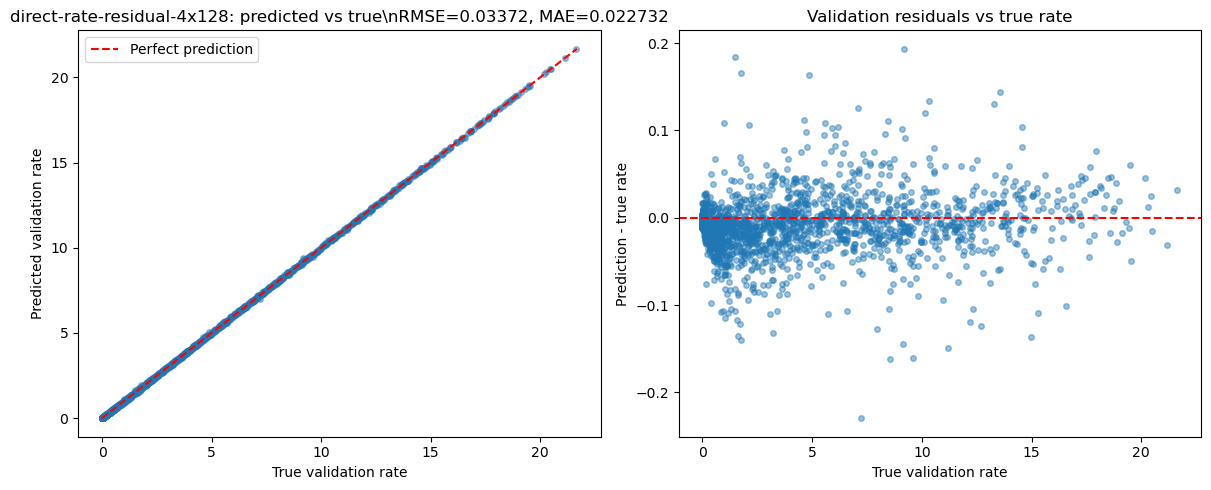

In [29]:
# Set a model key, or use None to select the lowest validation RMSE.
PLOT_MODEL_NAME = None
if not COMPLEXITY_MODELS:
    raise RuntimeError('Run at least one complexity test before plotting')
if PLOT_MODEL_NAME is None:
    PLOT_MODEL_NAME = min(
        COMPLEXITY_RESULTS, key=lambda key: COMPLEXITY_RESULTS[key]['val_rmse']
    )
if PLOT_MODEL_NAME not in COMPLEXITY_MODELS:
    raise KeyError(f'Unknown model {PLOT_MODEL_NAME!r}; available: {list(COMPLEXITY_MODELS)}')

plot_model = COMPLEXITY_MODELS[PLOT_MODEL_NAME]
plot_model.eval()
with torch.no_grad():
    validation_predictions = plot_model(complexity_x_val).squeeze(1).numpy()
validation_truth = complexity_y_val.squeeze(1).numpy()
validation_residuals = validation_predictions - validation_truth
if not np.isfinite(validation_predictions).all():
    raise FloatingPointError('Validation predictions contain non-finite values')

plot_min = min(validation_truth.min(), validation_predictions.min())
plot_max = max(validation_truth.max(), validation_predictions.max())
plot_rmse = np.sqrt(np.mean(validation_residuals ** 2))
plot_mae = np.mean(np.abs(validation_residuals))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(validation_truth, validation_predictions, alpha=0.45, s=16)
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], 'r--', label='Perfect prediction')
axes[0].set_xlabel('True validation rate')
axes[0].set_ylabel('Predicted validation rate')
axes[0].set_title(f'{PLOT_MODEL_NAME}: predicted vs true\nRMSE={plot_rmse:.5g}, MAE={plot_mae:.5g}')
axes[0].legend()

axes[1].scatter(validation_truth, validation_residuals, alpha=0.45, s=16)
axes[1].axhline(0.0, color='r', linestyle='--')
axes[1].set_xlabel('True validation rate')
axes[1].set_ylabel('Prediction - true rate')
axes[1].set_title('Validation residuals vs true rate')
fig.tight_layout()
plt.show()